# 05 — Final Evaluation and Explainability

This notebook performs the final evaluation of the COPD forecasting models on the independent 2023 test set.

The workflow includes:

- reconstruction of the final selected predictor sets;
- training of the 12 final model configurations using the complete 2010–2022 development period;
- evaluation on the unseen 2023 test year;
- calculation of classification and discrimination metrics;
- ROC-curve analysis;
- confusion-matrix analysis;
- SHAP-based model explainability.

The 2023 observations are used exclusively for final evaluation and are not involved in feature selection, preprocessing decisions or temporal cross-validation.

In [31]:
%load_ext autoreload
%autoreload 2

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_curve,
)

from copd_forecasting.config import (
    PROCESSED_DATA_FILE,
    FEATURE_SELECTION_FILE,
    DATE_COLUMN,
    TEST_YEAR,
    FINAL_METRICS_FILE,
    SHAP_IMPORTANCE_FILE,
)

from copd_forecasting.features import (
    add_temporal_features,
    create_binary_target,
    build_subset_a,
    build_subset_b,
)

from copd_forecasting.selection import (
    prepare_feature_subset,
)

from copd_forecasting.models import (
    MODEL_NAMES,
    OPTIMAL_PARAMS,
    train_final_model,
)

from copd_forecasting.evaluation import (
    calculate_classification_metrics,
)

import shap

from copd_forecasting.explainability import (
    compute_shap_values,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Reconstruct final modelling datasets

The cleaned dataset and previously stored feature-selection results are used to reconstruct the exact predictor sets used during temporal validation.

All preprocessing parameters are fitted using the 2010–2022 development period and subsequently applied to the independent 2023 test set.

In [3]:
df = pd.read_excel(
    PROCESSED_DATA_FILE,
    parse_dates=[DATE_COLUMN],
)

df = (
    df
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

df = add_temporal_features(df)

y = create_binary_target(df)

subset_a = build_subset_a(df)
subset_b = build_subset_b(df)

In [4]:
development_mask = (
    df[DATE_COLUMN].dt.year
    < TEST_YEAR
).to_numpy()

test_mask = (
    df[DATE_COLUMN].dt.year
    == TEST_YEAR
).to_numpy()

y_development = (
    y[development_mask]
    .to_numpy()
)

y_test = (
    y[test_mask]
    .to_numpy()
)

print(
    f"Development: "
    f"{development_mask.sum():,} samples"
)

print(
    f"Independent test: "
    f"{test_mask.sum():,} samples"
)

Development: 4,741 samples
Independent test: 365 samples


In [5]:
prepared_a = prepare_feature_subset(
    subset_a,
    development_mask,
    test_mask,
    correlation_threshold=0.8,
)

prepared_b = prepare_feature_subset(
    subset_b,
    development_mask,
    test_mask,
    correlation_threshold=0.8,
)

In [6]:
with open(
    FEATURE_SELECTION_FILE,
    "r",
    encoding="utf-8",
) as file:
    feature_selection = json.load(file)

selected_a = feature_selection[
    "subset_a"
]["selected_features"]

selected_b = feature_selection[
    "subset_b"
]["selected_features"]

In [7]:
def select_columns(
    prepared_subset: dict,
    selected_features: list[str],
):
    indices = [
        prepared_subset[
            "features"
        ].index(feature)
        for feature
        in selected_features
    ]

    return (
        prepared_subset[
            "X_development"
        ][:, indices],
        prepared_subset[
            "X_test"
        ][:, indices],
    )

In [8]:
X_dev_a, X_test_a = select_columns(
    prepared_a,
    selected_a,
)

X_dev_b, X_test_b = select_columns(
    prepared_b,
    selected_b,
)

print(
    f"Subset A: "
    f"{X_dev_a.shape} → {X_test_a.shape}"
)

print(
    f"Subset B: "
    f"{X_dev_b.shape} → {X_test_b.shape}"
)

Subset A: (4741, 6) → (365, 6)
Subset B: (4741, 24) → (365, 24)


## 2. Final model training

Each final configuration is retrained using the complete 2010–2022 development period.

The corresponding optimal hyperparameters identified through either sliding-window or expanding-window validation are retained. Predictions are then generated for the independent 2023 test set using a decision threshold of 0.5.

In [9]:
FINAL_SUBSETS = {
    "a": {
        "X_train": X_dev_a,
        "X_test": X_test_a,
        "features": selected_a,
    },
    "b": {
        "X_train": X_dev_b,
        "X_test": X_test_b,
        "features": selected_b,
    },
}

In [10]:
final_results = {}

for strategy in [
    "sliding",
    "expanding",
]:
    final_results[
        strategy
    ] = {}

    for model_name in MODEL_NAMES:
        final_results[
            strategy
        ][model_name] = {}

        for subset_name in [
            "a",
            "b",
        ]:
            X_train = FINAL_SUBSETS[
                subset_name
            ]["X_train"]

            X_test = FINAL_SUBSETS[
                subset_name
            ]["X_test"]

            feature_names = FINAL_SUBSETS[
                subset_name
            ]["features"]

            params = OPTIMAL_PARAMS[
                strategy
            ][model_name][subset_name]

            model = train_final_model(
                model_name=model_name,
                X_train=X_train,
                y_train=y_development,
                params=params,
            )

            if model_name == "LightGBM":
                X_test_model = pd.DataFrame(
                    X_test,
                    columns=[
                        f"feature_{i}"
                        for i in range(
                            X_test.shape[1]
                        )
                    ],
                )
            else:
                X_test_model = X_test

            probabilities = (
                model.predict_proba(
                    X_test_model
                )[:, 1]
            )

            predictions = (
                probabilities >= 0.5
            ).astype(int)

            final_results[
                strategy
            ][model_name][
                subset_name
            ] = {
                "model": model,
                "probabilities": probabilities,
                "predictions": predictions,
                "X_train": X_train,
                "X_test": X_test,
                "feature_names": feature_names,
            }

            print(
                f"{strategy:9s} | "
                f"{model_name:8s} | "
                f"Subset "
                f"{subset_name.upper()} "
                f"completed"
            )

sliding   | LightGBM | Subset A completed
sliding   | LightGBM | Subset B completed
sliding   | CatBoost | Subset A completed
sliding   | CatBoost | Subset B completed
sliding   | MLP      | Subset A completed
sliding   | MLP      | Subset B completed
expanding | LightGBM | Subset A completed
expanding | LightGBM | Subset B completed
expanding | CatBoost | Subset A completed
expanding | CatBoost | Subset B completed
expanding | MLP      | Subset A completed
expanding | MLP      | Subset B completed


In [11]:
metric_records = []

for strategy in final_results:
    for model_name in (
        final_results[strategy]
    ):
        for subset_name in (
            final_results[
                strategy
            ][model_name]
        ):
            result = final_results[
                strategy
            ][model_name][
                subset_name
            ]

            metrics = (
                calculate_classification_metrics(
                    y_true=y_test,
                    y_pred=result[
                        "predictions"
                    ],
                    y_prob=result[
                        "probabilities"
                    ],
                )
            )

            metric_records.append(
                {
                    "Strategy": strategy,
                    "Subset": (
                        subset_name.upper()
                    ),
                    "Model": model_name,
                    **metrics,
                }
            )

final_metrics = pd.DataFrame(
    metric_records
)

final_metrics.round(3)

,Strategy,Subset,Model,TP,FP,TN,FN,Sensitivity,Specificity,PPV,NPV,LR+,LR-,Accuracy,F1,Balanced_Accuracy,AUC_ROC,AUC_PR
0,sliding,A,LightGBM,90,55,108,112,0.446,0.663,0.621,0.491,1.320,0.837,0.542,0.519,0.554,0.590,0.636
1,sliding,B,LightGBM,102,53,110,100,0.505,0.675,0.658,0.524,1.553,0.734,0.581,0.571,0.590,0.608,0.650
2,sliding,A,CatBoost,86,49,114,116,0.426,0.699,0.637,0.496,1.416,0.821,0.548,0.510,0.563,0.624,0.655
3,sliding,B,CatBoost,101,60,103,101,0.500,0.632,0.627,0.505,1.358,0.791,0.559,0.556,0.566,0.603,0.644
4,sliding,A,MLP,132,80,83,70,0.653,0.509,0.623,0.542,1.331,0.681,0.589,0.638,0.581,0.593,0.647
5,sliding,B,MLP,141,98,65,61,0.698,0.399,0.590,0.516,1.161,0.757,0.564,0.639,0.548,0.602,0.653
6,expanding,A,LightGBM,93,57,106,109,0.460,0.650,0.620,0.493,1.317,0.830,0.545,0.528,0.555,0.576,0.624
7,expanding,B,LightGBM,101,52,111,101,0.500,0.681,0.660,0.524,1.567,0.734,0.581,0.569,0.590,0.603,0.639
8,expanding,A,CatBoost,91,47,116,111,0.450,0.712,0.659,0.511,1.562,0.772,0.567,0.535,0.581,0.619,0.658
9,expanding,B,CatBoost,103,63,100,99,0.510,0.613,0.620,0.503,1.319,0.799,0.556,0.560,0.562,0.589,0.646


## 3. Final test performance

Performance is evaluated on the independent 2023 test set using classification and discrimination metrics.

Results are presented separately for each validation strategy and predictor subset.

In [12]:
PERCENT_METRICS = [
    "Sensitivity",
    "Specificity",
    "PPV",
    "NPV",
    "Accuracy",
    "F1",
    "Balanced_Accuracy",
]

METRIC_ORDER = [
    "Sensitivity",
    "Specificity",
    "PPV",
    "NPV",
    "LR+",
    "LR-",
    "Accuracy",
    "F1",
    "Balanced_Accuracy",
    "AUC_ROC",
    "AUC_PR",
]


def build_performance_table(
    metrics_df: pd.DataFrame,
    strategy: str,
    subset: str,
) -> pd.DataFrame:
    """Create a presentation-ready performance table."""

    table = (
        metrics_df.loc[
            (metrics_df["Strategy"] == strategy)
            & (metrics_df["Subset"] == subset)
        ]
        .set_index("Model")[METRIC_ORDER]
        .T
    )

    table = table[
        MODEL_NAMES
    ].copy()

    for metric in PERCENT_METRICS:
        table.loc[metric] *= 100

    table = table.round(3)

    return table

In [13]:
sliding_a_table = build_performance_table(
    final_metrics,
    strategy="sliding",
    subset="A",
)

sliding_a_table

Model,LightGBM,CatBoost,MLP
Sensitivity,44.554,42.574,65.347
Specificity,66.258,69.939,50.920
PPV,62.069,63.704,62.264
NPV,49.091,49.565,54.248
LR+,1.320,1.416,1.331
LR-,0.837,0.821,0.681
Accuracy,54.247,54.795,58.904
F1,51.873,51.039,63.768
Balanced_Accuracy,55.406,56.256,58.133
AUC_ROC,0.590,0.624,0.593


In [14]:
sliding_b_table = build_performance_table(
    final_metrics,
    strategy="sliding",
    subset="B",
)

sliding_b_table

Model,LightGBM,CatBoost,MLP
Sensitivity,50.495,50.000,69.802
Specificity,67.485,63.190,39.877
PPV,65.806,62.733,58.996
NPV,52.381,50.490,51.587
LR+,1.553,1.358,1.161
LR-,0.734,0.791,0.757
Accuracy,58.082,55.890,56.438
F1,57.143,55.647,63.946
Balanced_Accuracy,58.990,56.595,54.840
AUC_ROC,0.608,0.603,0.602


In [15]:
expanding_a_table = build_performance_table(
    final_metrics,
    strategy="expanding",
    subset="A",
)

expanding_a_table

Model,LightGBM,CatBoost,MLP
Sensitivity,46.040,45.050,53.960
Specificity,65.031,71.166,57.055
PPV,62.000,65.942,60.894
NPV,49.302,51.101,50.000
LR+,1.317,1.562,1.257
LR-,0.830,0.772,0.807
Accuracy,54.521,56.712,55.342
F1,52.841,53.529,57.218
Balanced_Accuracy,55.535,58.108,55.508
AUC_ROC,0.576,0.619,0.609


In [16]:
expanding_b_table = build_performance_table(
    final_metrics,
    strategy="expanding",
    subset="B",
)

expanding_b_table

Model,LightGBM,CatBoost,MLP
Sensitivity,50.000,50.990,72.772
Specificity,68.098,61.350,36.810
PPV,66.013,62.048,58.800
NPV,52.358,50.251,52.174
LR+,1.567,1.319,1.152
LR-,0.734,0.799,0.740
Accuracy,58.082,55.616,56.712
F1,56.901,55.978,65.044
Balanced_Accuracy,59.049,56.170,54.791
AUC_ROC,0.603,0.589,0.605


## 4. ROC-curve analysis

Receiver operating characteristic (ROC) curves are used to compare the discrimination ability of LightGBM, CatBoost and MLP on the independent 2023 test set.

An AUC-ROC of 0.5 represents random discrimination.

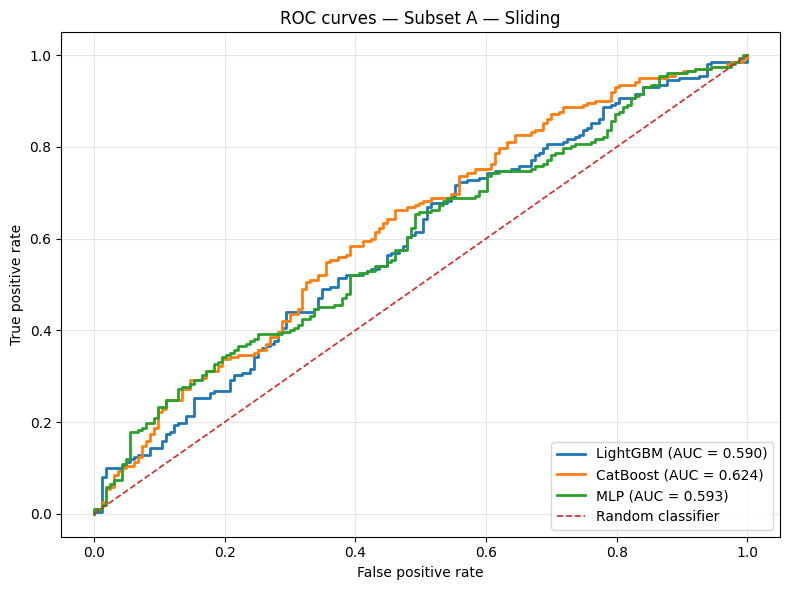

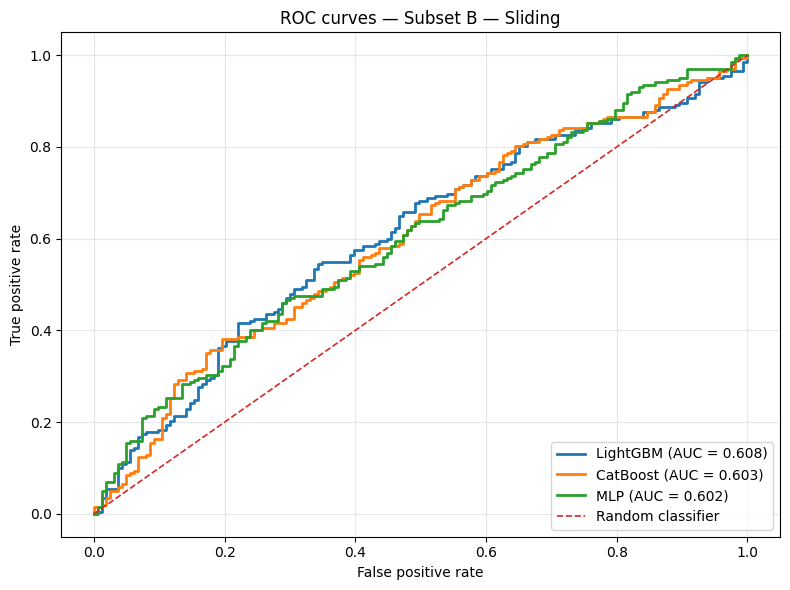

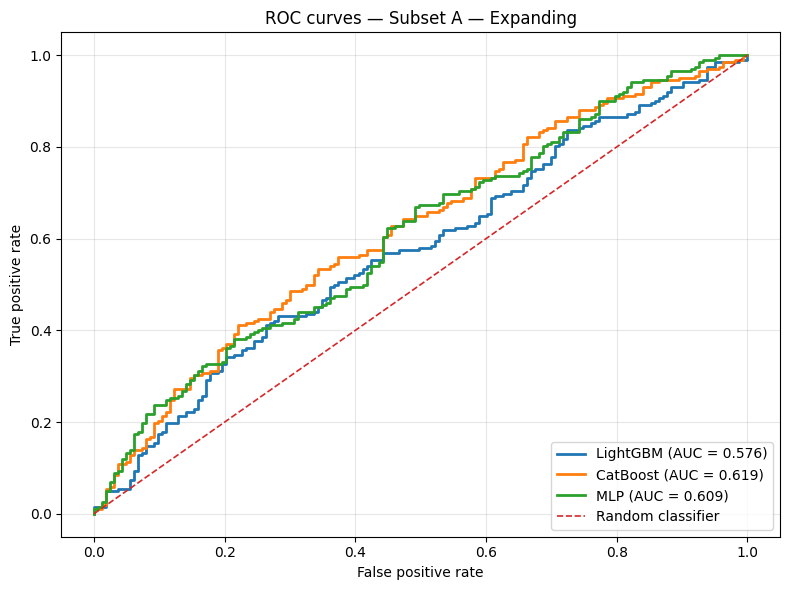

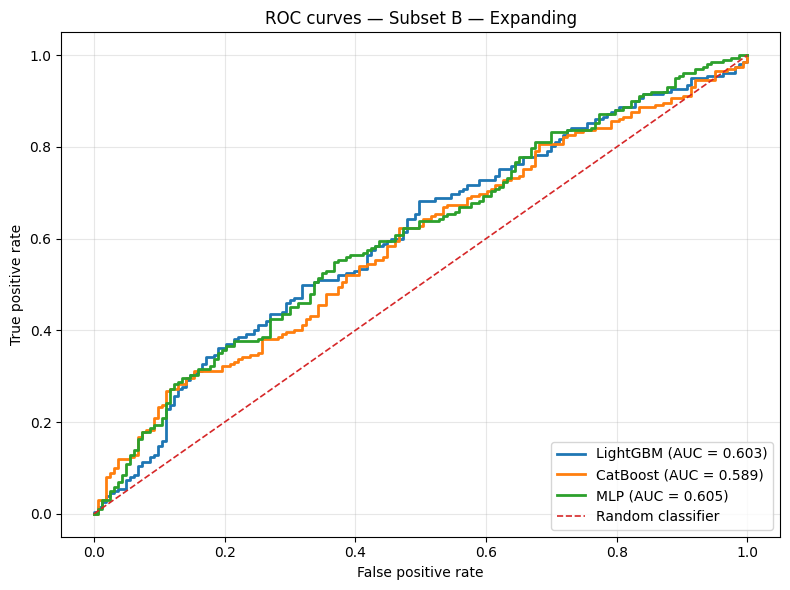

In [18]:
for strategy in [
    "sliding",
    "expanding",
]:
    for subset_name in [
        "a",
        "b",
    ]:
        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        for model_name in MODEL_NAMES:
            probabilities = (
                final_results[
                    strategy
                ][model_name][
                    subset_name
                ]["probabilities"]
            )

            fpr, tpr, _ = roc_curve(
                y_test,
                probabilities,
            )

            auc = roc_auc_score(
                y_test,
                probabilities,
            )

            ax.plot(
                fpr,
                tpr,
                linewidth=2,
                label=(
                    f"{model_name} "
                    f"(AUC = {auc:.3f})"
                ),
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1.2,
            label="Random classifier",
        )

        ax.set_title(
            f"ROC curves — Subset "
            f"{subset_name.upper()} — "
            f"{strategy.capitalize()}"
        )

        ax.set_xlabel(
            "False positive rate"
        )

        ax.set_ylabel(
            "True positive rate"
        )

        ax.legend(
            loc="lower right"
        )

        ax.grid(
            alpha=0.3
        )

        plt.tight_layout()
        plt.show()

## 5. Confusion-matrix analysis

Confusion matrices show the absolute number of correct and incorrect classifications obtained using the fixed decision threshold of 0.5.

They provide a direct view of the trade-off between detecting positive days and avoiding false alarms.

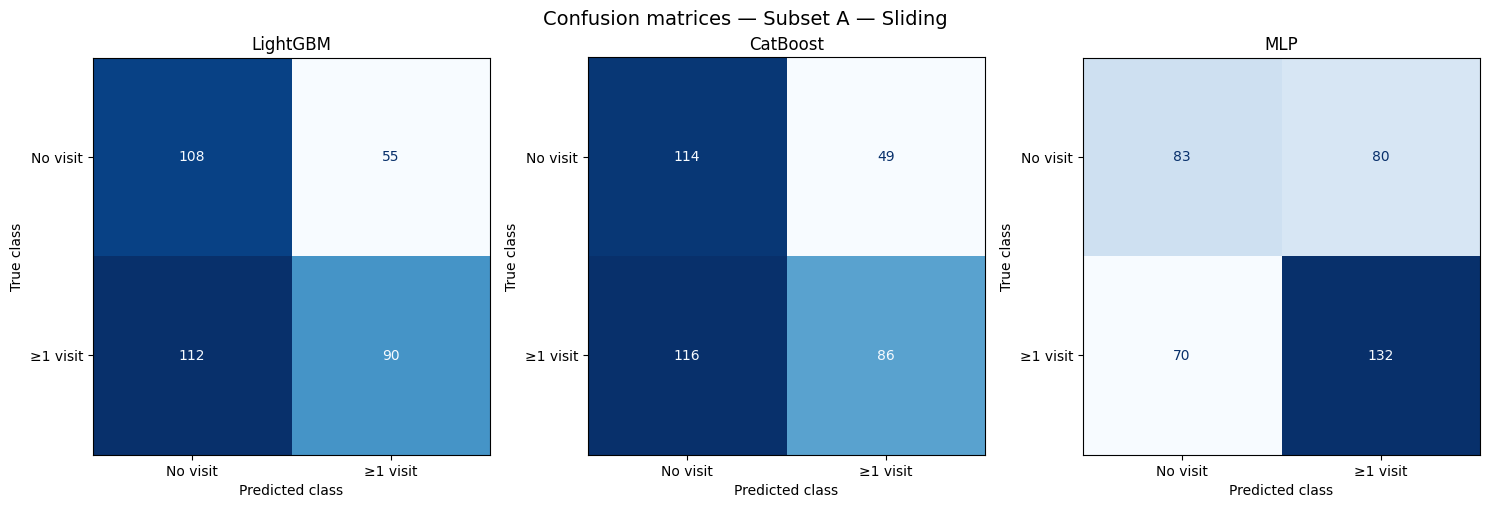

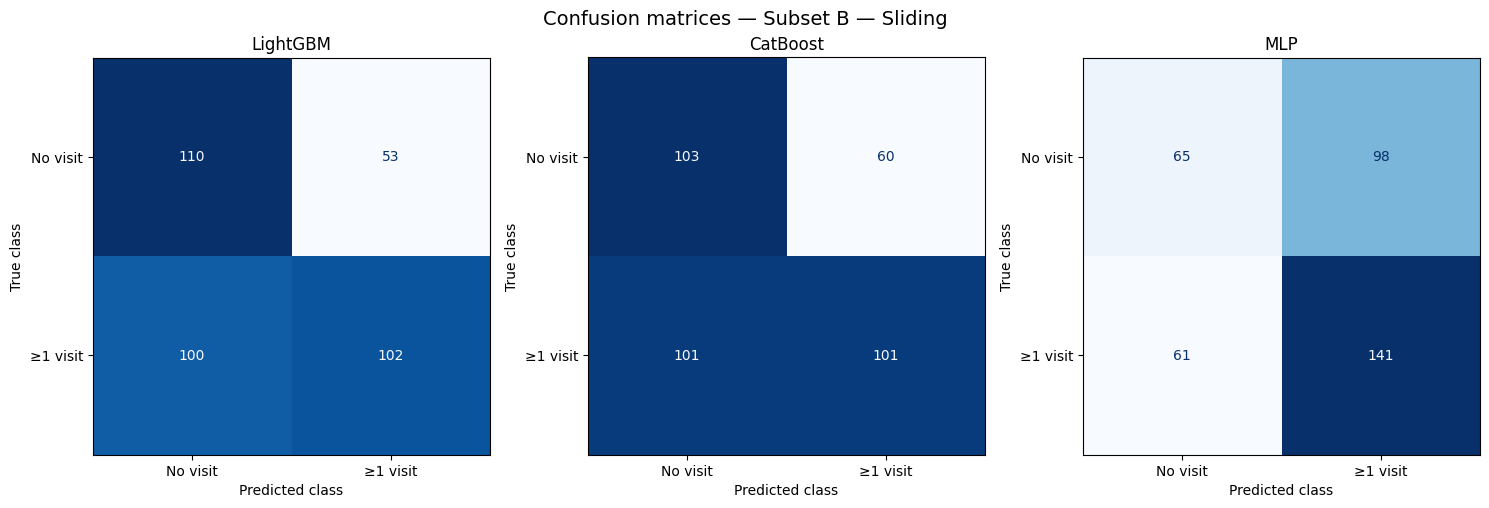

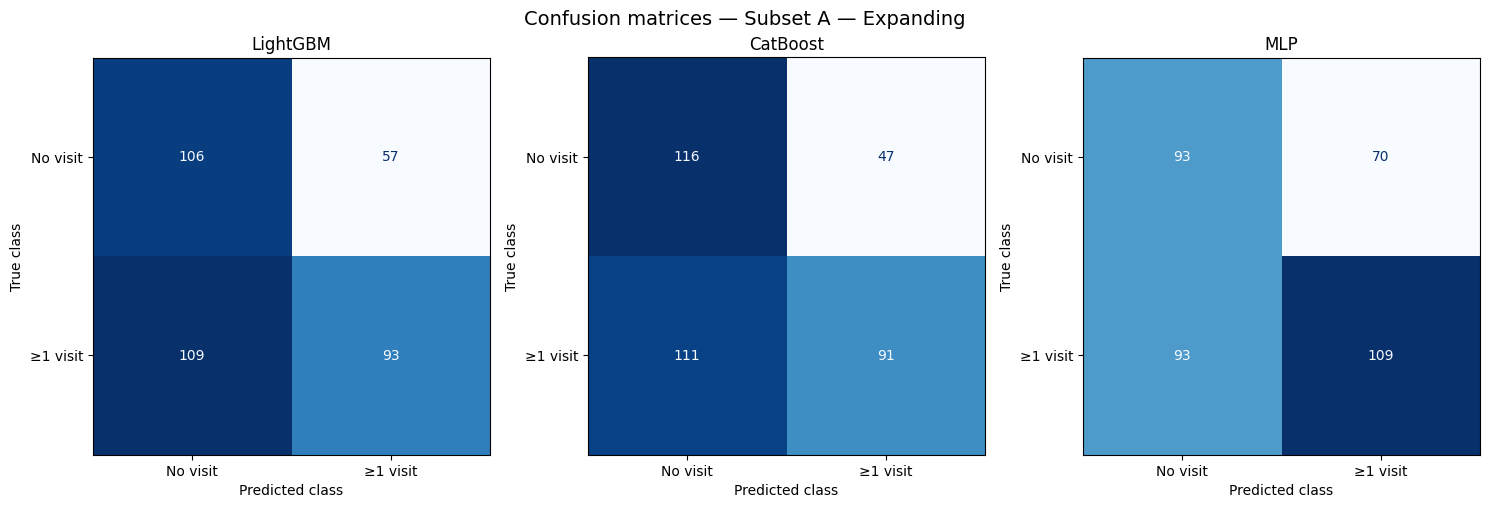

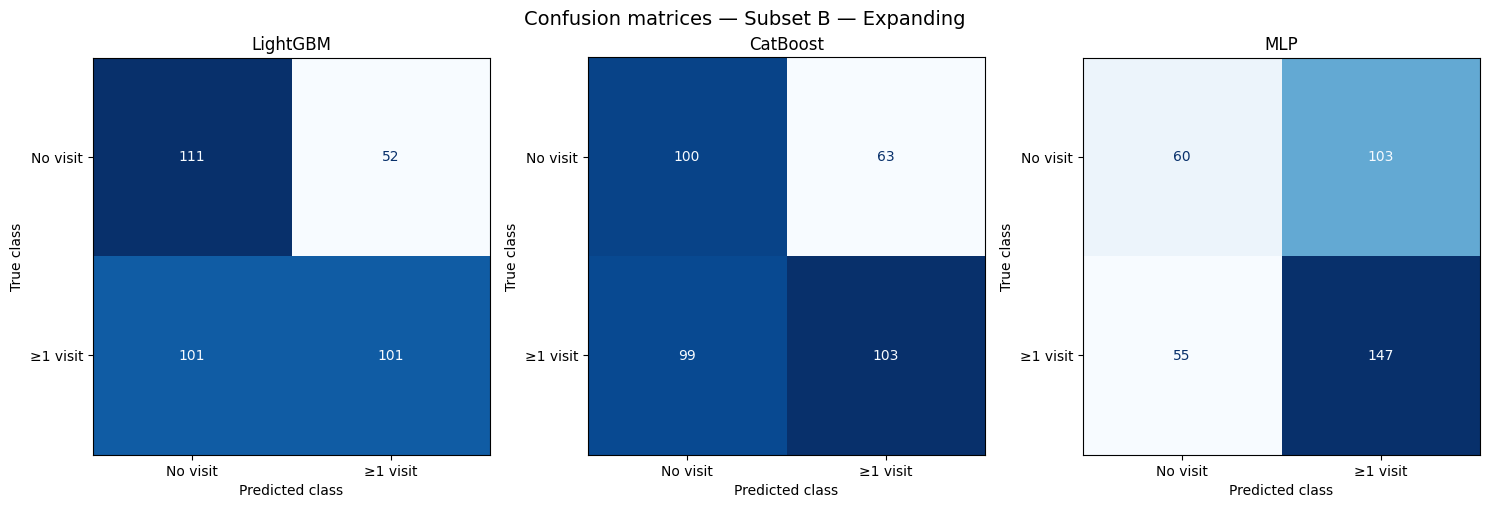

In [19]:
for strategy in [
    "sliding",
    "expanding",
]:
    for subset_name in [
        "a",
        "b",
    ]:
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 5),
        )

        for ax, model_name in zip(
            axes,
            MODEL_NAMES,
        ):
            predictions = (
                final_results[
                    strategy
                ][model_name][
                    subset_name
                ]["predictions"]
            )

            cm = confusion_matrix(
                y_test,
                predictions,
            )

            display = (
                ConfusionMatrixDisplay(
                    confusion_matrix=cm,
                    display_labels=[
                        "No visit",
                        "≥1 visit",
                    ],
                )
            )

            display.plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format="d",
            )

            ax.set_title(
                model_name
            )

            ax.set_xlabel(
                "Predicted class"
            )

            ax.set_ylabel(
                "True class"
            )

        fig.suptitle(
            f"Confusion matrices — "
            f"Subset "
            f"{subset_name.upper()} — "
            f"{strategy.capitalize()}",
            fontsize=14,
        )

        plt.tight_layout()
        plt.show()

In [22]:
final_metrics.to_csv(
    FINAL_METRICS_FILE,
    index=False,
)

print(
    f"✓ Final test metrics saved to: "
    f"{FINAL_METRICS_FILE}"
)

✓ Final test metrics saved to: C:\Users\migue\Desktop\Healthcare-AI\copd-exacerbation-forecasting\reports\final_test_metrics.csv


## 6. SHAP explainability

SHAP values are calculated on the independent 2023 test set to examine how individual predictors contribute to model predictions.

TreeExplainer is used for LightGBM and CatBoost, while KernelExplainer is used for the multilayer perceptron.

Positive SHAP values indicate contributions that increase the modelled probability of at least one COPD-related emergency visit, whereas negative values decrease it relative to the model baseline.

These explanations describe model behaviour and should not be interpreted as evidence of causal relationships.

In [24]:
shap_results = {}

for strategy in [
    "sliding",
    "expanding",
]:
    for subset_name in [
        "a",
        "b",
    ]:
        for model_name in MODEL_NAMES:
            result = final_results[
                strategy
            ][model_name][
                subset_name
            ]

            print(
                f"SHAP | "
                f"{strategy:9s} | "
                f"{model_name:8s} | "
                f"Subset "
                f"{subset_name.upper()}"
            )

            shap_result = (
                compute_shap_values(
                    model_name=model_name,
                    model=result["model"],
                    X_train=result[
                        "X_train"
                    ],
                    X_test=result[
                        "X_test"
                    ],
                    background_size=100,
                    kernel_nsamples=200,
                )
            )

            shap_results[
                (
                    strategy,
                    model_name,
                    subset_name,
                )
            ] = {
                **shap_result,
                "X_test": result[
                    "X_test"
                ],
                "feature_names": result[
                    "feature_names"
                ],
            }

SHAP | sliding   | LightGBM | Subset A
SHAP | sliding   | CatBoost | Subset A
SHAP | sliding   | MLP      | Subset A


100%|██████████| 365/365 [00:06<00:00, 56.08it/s] 


SHAP | sliding   | LightGBM | Subset B
SHAP | sliding   | CatBoost | Subset B
SHAP | sliding   | MLP      | Subset B


100%|██████████| 365/365 [00:26<00:00, 13.66it/s]


SHAP | expanding | LightGBM | Subset A
SHAP | expanding | CatBoost | Subset A
SHAP | expanding | MLP      | Subset A


100%|██████████| 365/365 [00:02<00:00, 154.29it/s]


SHAP | expanding | LightGBM | Subset B
SHAP | expanding | CatBoost | Subset B
SHAP | expanding | MLP      | Subset B


100%|██████████| 365/365 [00:20<00:00, 17.62it/s]


In [25]:
for key, result in (
    shap_results.items()
):
    print(
        key,
        result[
            "shap_values"
        ].shape,
    )

('sliding', 'LightGBM', 'a') (365, 6)
('sliding', 'CatBoost', 'a') (365, 6)
('sliding', 'MLP', 'a') (365, 6)
('sliding', 'LightGBM', 'b') (365, 24)
('sliding', 'CatBoost', 'b') (365, 24)
('sliding', 'MLP', 'b') (365, 24)
('expanding', 'LightGBM', 'a') (365, 6)
('expanding', 'CatBoost', 'a') (365, 6)
('expanding', 'MLP', 'a') (365, 6)
('expanding', 'LightGBM', 'b') (365, 24)
('expanding', 'CatBoost', 'b') (365, 24)
('expanding', 'MLP', 'b') (365, 24)


## 7. SHAP beeswarm plots

Beeswarm plots summarise both the global importance and direction of predictor contributions.

Each point represents one test observation:

- horizontal position indicates the SHAP contribution;
- colour represents the predictor value;
- predictors are ordered by mean absolute SHAP magnitude.

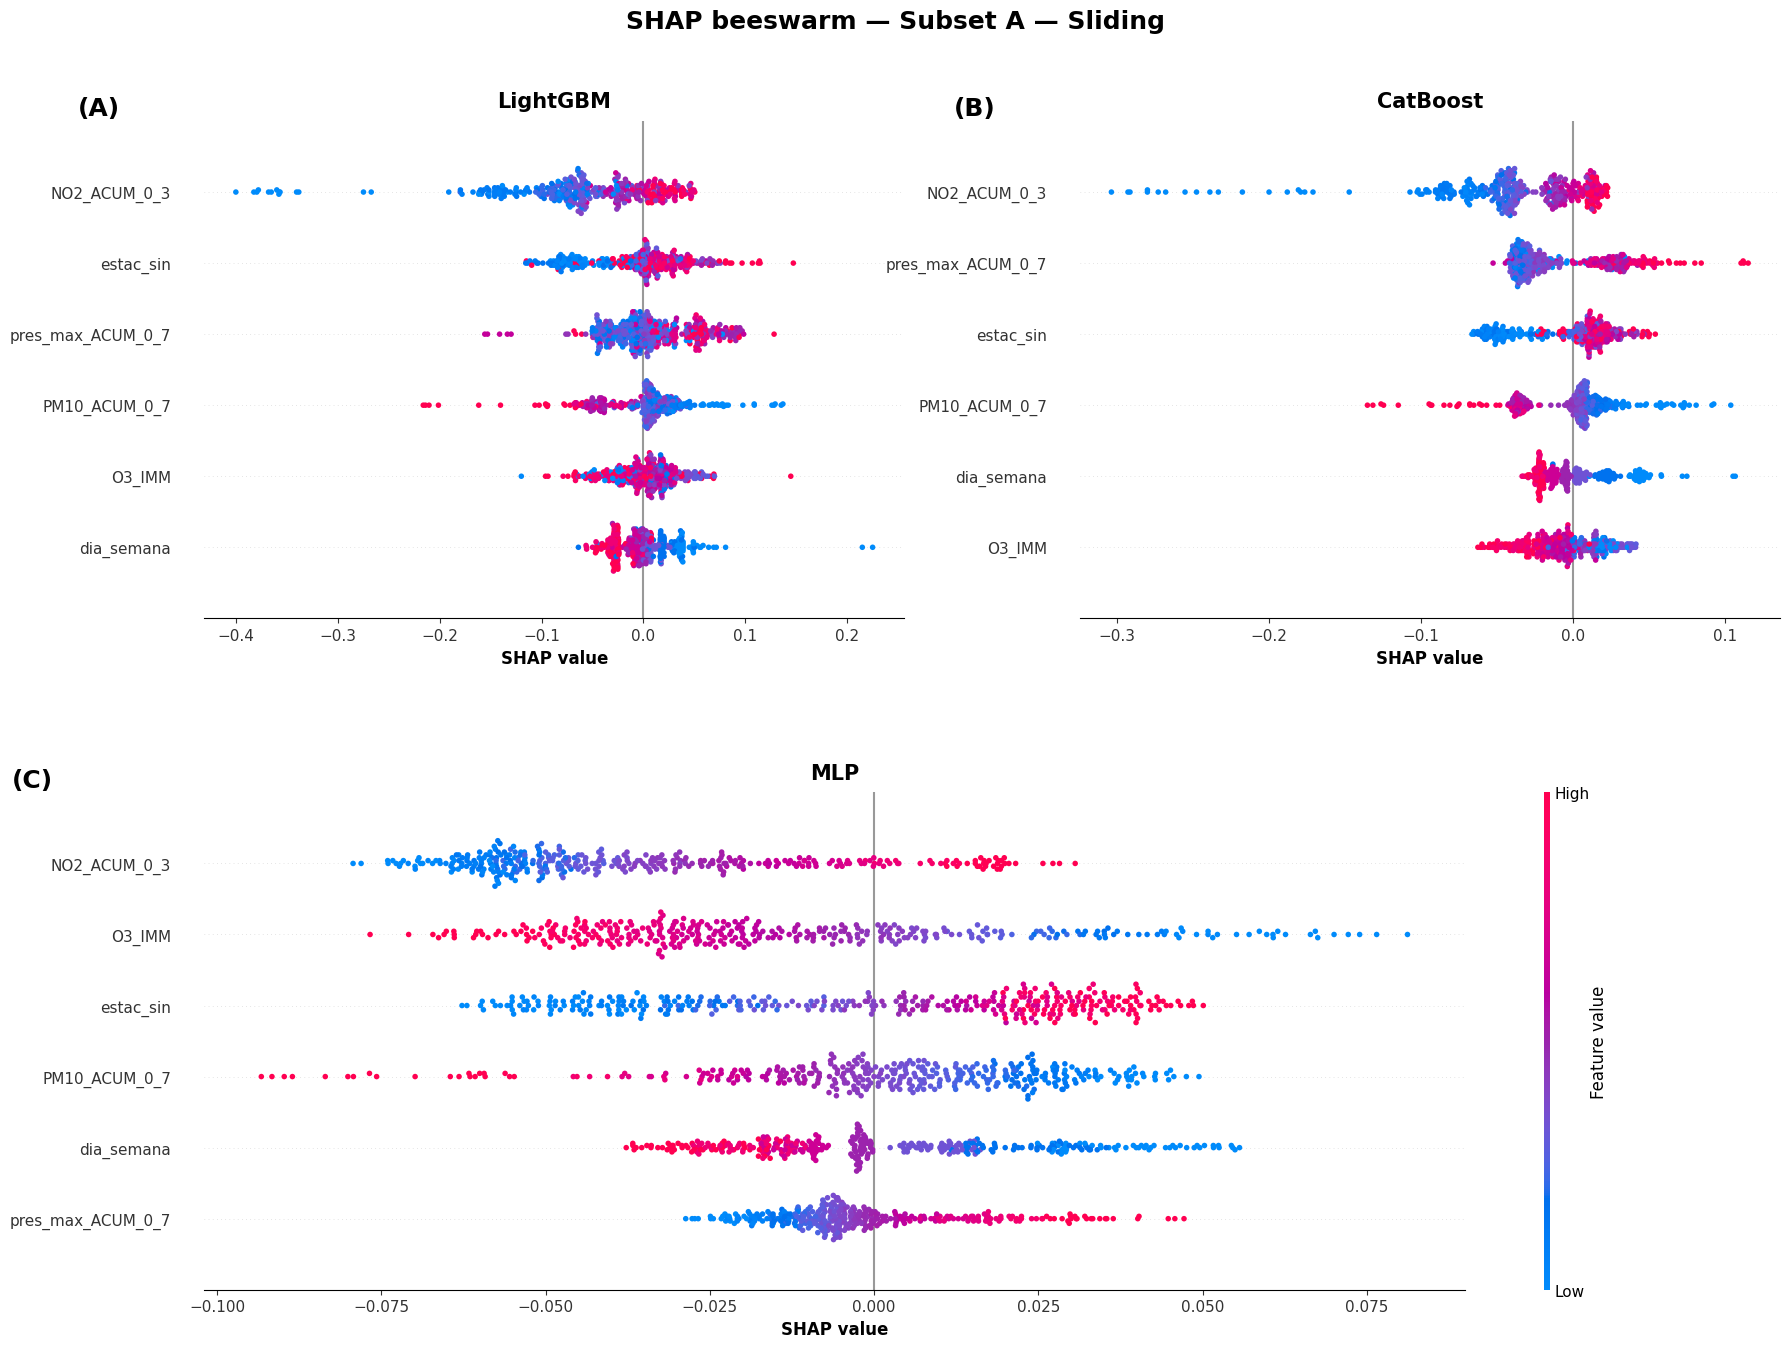

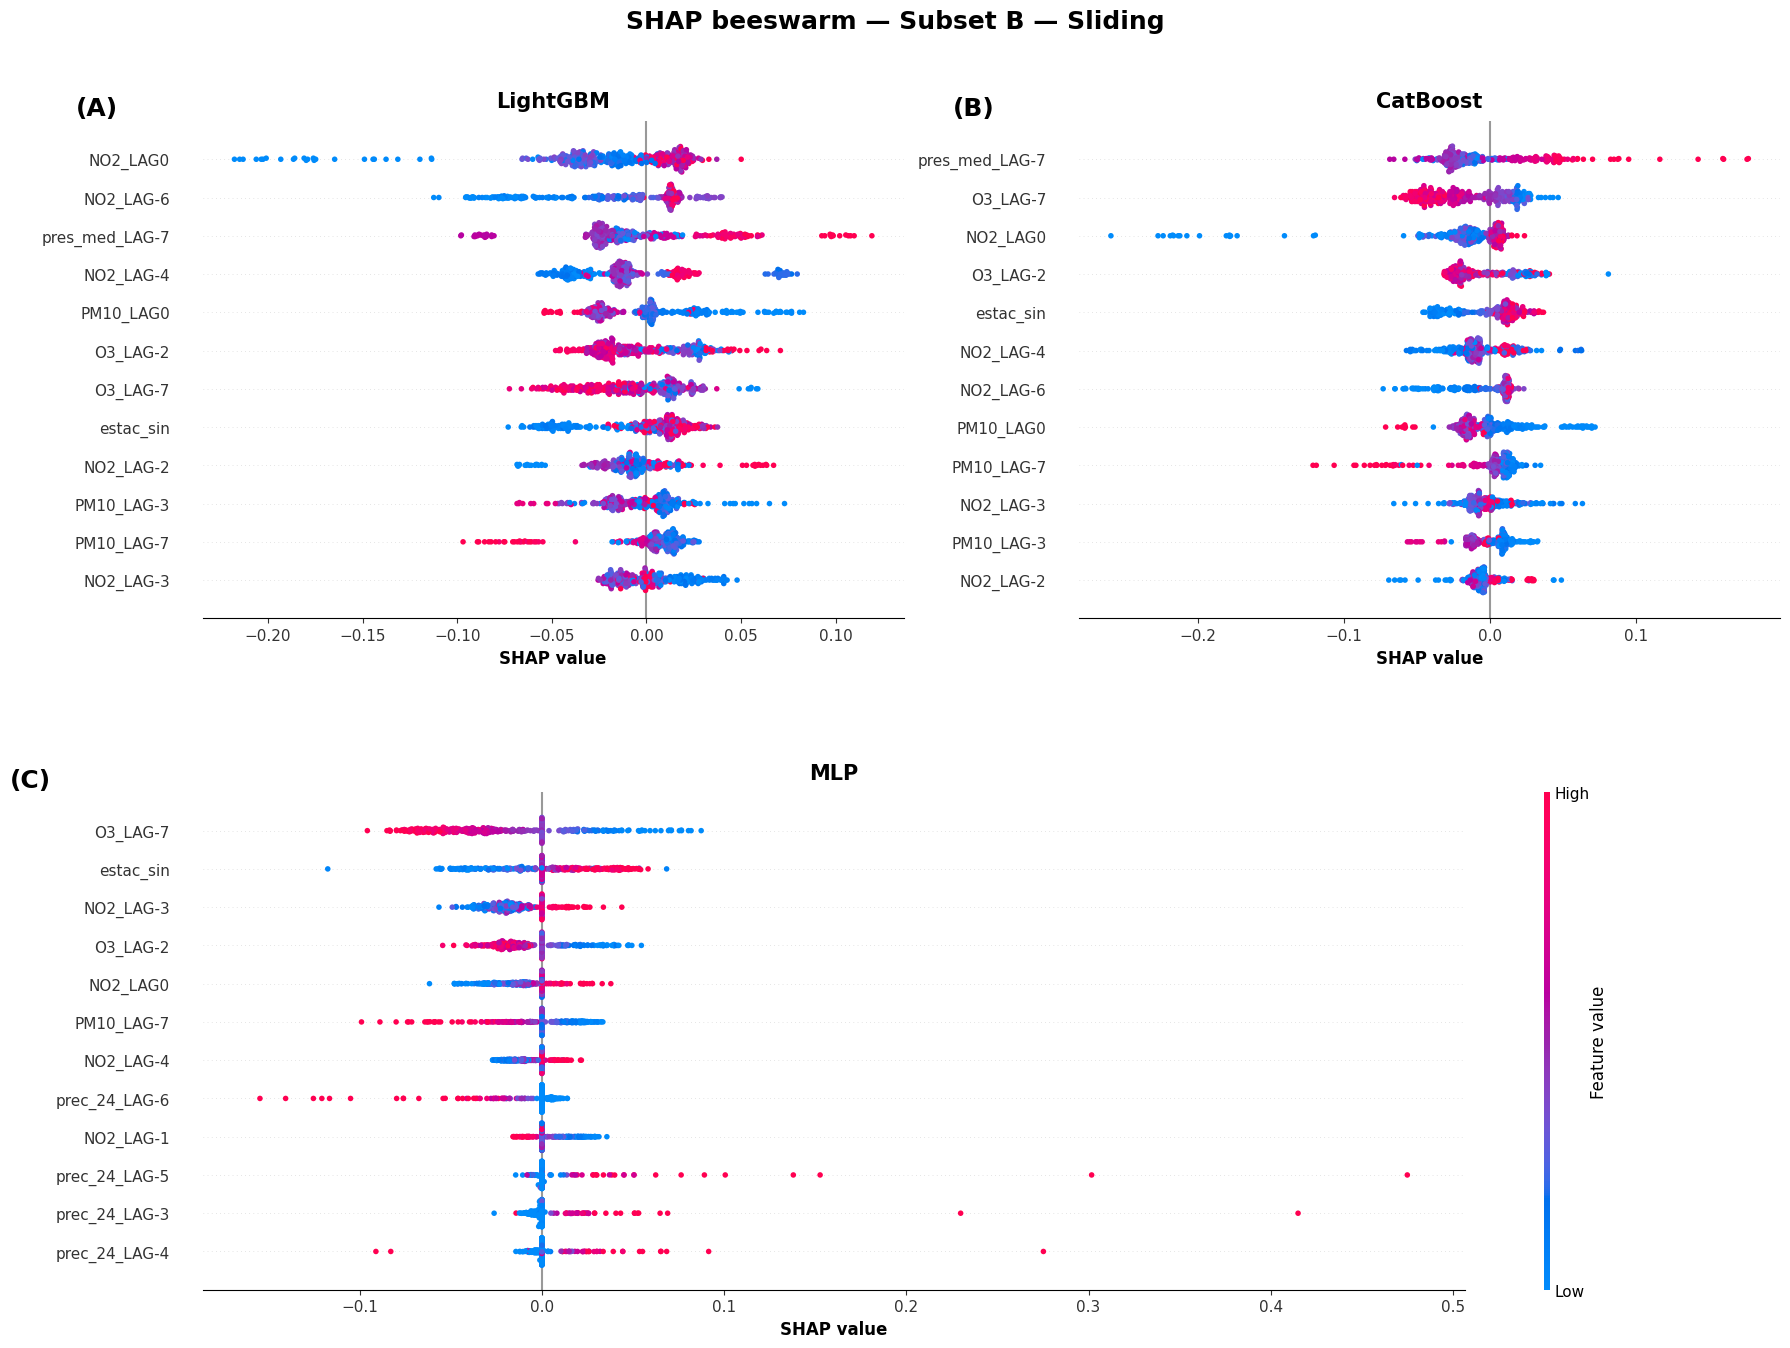

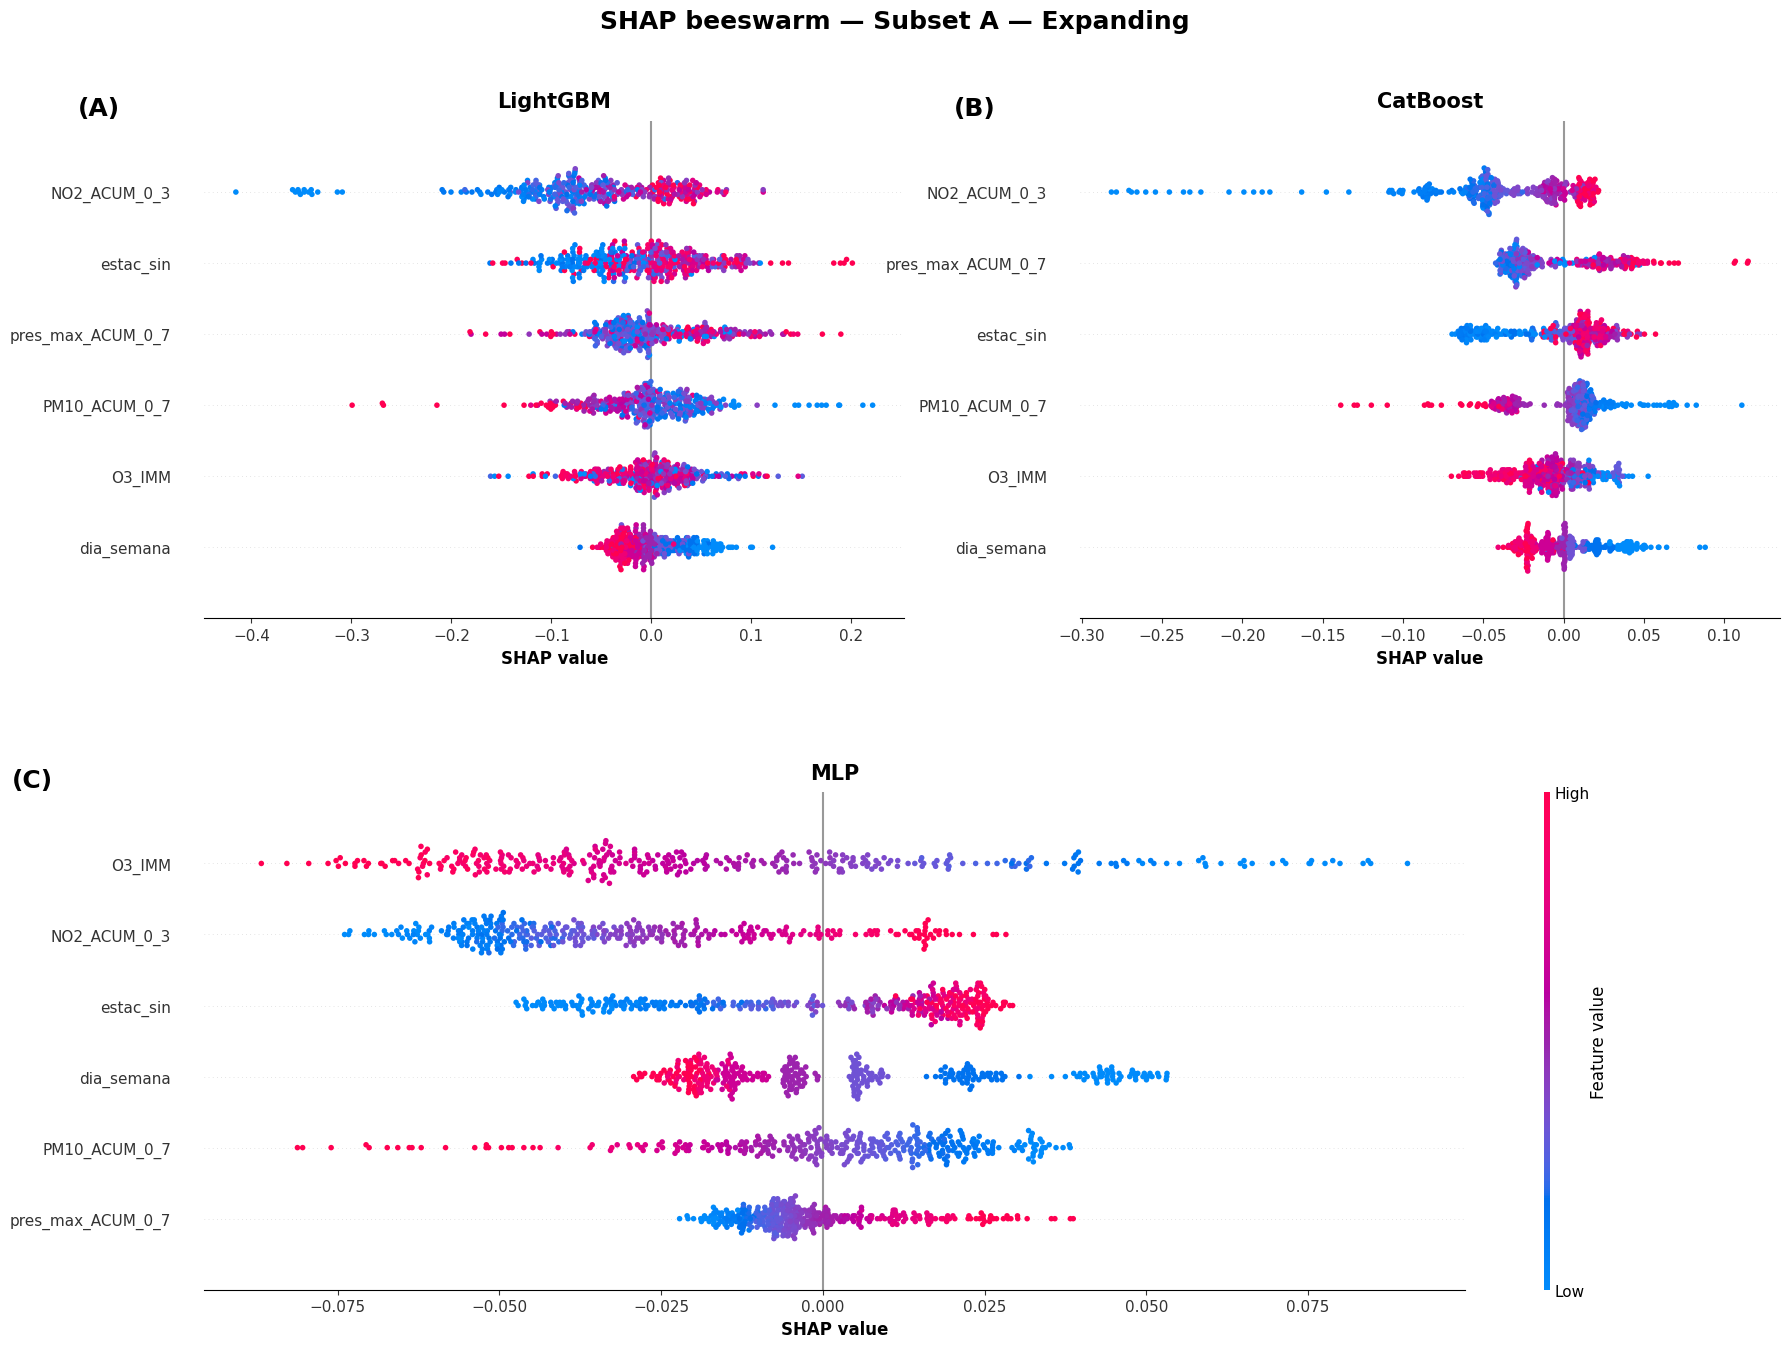

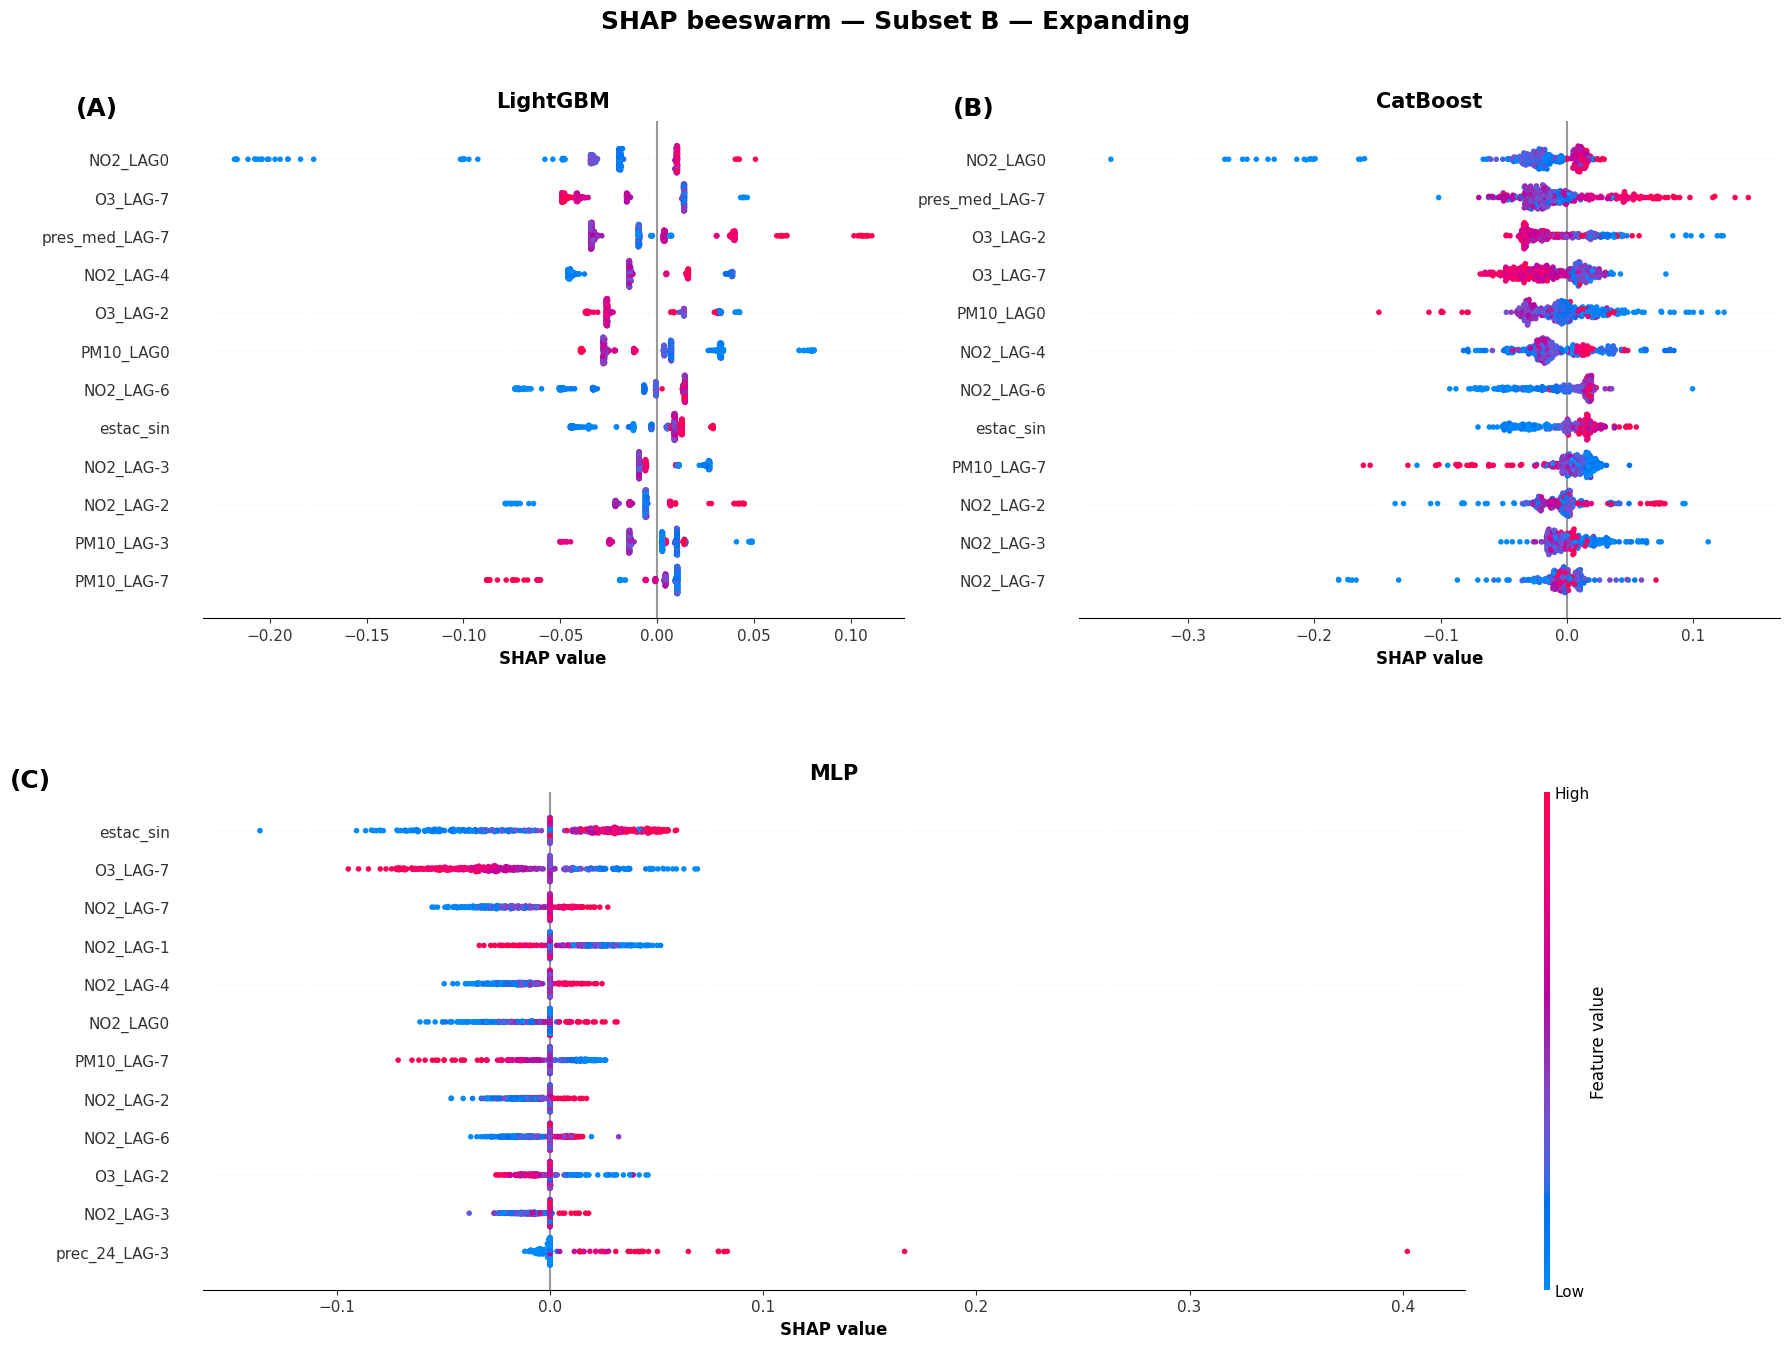

In [26]:
PANEL_LABELS = {
    0: "(A)",
    1: "(B)",
    2: "(C)",
}

for strategy in [
    "sliding",
    "expanding",
]:
    for subset_name in [
        "a",
        "b",
    ]:
        fig = plt.figure(
            figsize=(18, 14)
        )

        fig.suptitle(
            f"SHAP beeswarm — "
            f"Subset "
            f"{subset_name.upper()} — "
            f"{strategy.capitalize()}",
            fontsize=18,
            fontweight="bold",
            y=0.96,
        )

        ax1 = plt.subplot2grid(
            (2, 2),
            (0, 0),
        )

        ax2 = plt.subplot2grid(
            (2, 2),
            (0, 1),
        )

        ax3 = plt.subplot2grid(
            (2, 2),
            (1, 0),
            colspan=2,
        )

        axes = [
            ax1,
            ax2,
            ax3,
        ]

        for j, model_name in enumerate(
            MODEL_NAMES
        ):
            result = shap_results[
                (
                    strategy,
                    model_name,
                    subset_name,
                )
            ]

            ax = axes[j]

            ax.text(
                -0.12,
                1.05,
                PANEL_LABELS[j],
                transform=ax.transAxes,
                fontsize=18,
                fontweight="bold",
                va="top",
                ha="right",
            )

            plt.sca(ax)

            shap.summary_plot(
                result[
                    "shap_values"
                ],
                result[
                    "X_test"
                ],
                feature_names=result[
                    "feature_names"
                ],
                plot_type="dot",
                max_display=12,
                show=False,
                color_bar=(j == 2),
                plot_size=None,
            )

            ax.set_title(
                model_name,
                fontsize=15,
                fontweight="bold",
                pad=10,
            )

            ax.set_xlabel(
                "SHAP value",
                fontsize=12,
                fontweight="bold",
            )

            ax.tick_params(
                axis="both",
                labelsize=11,
            )

        plt.tight_layout()

        plt.subplots_adjust(
            top=0.88,
            hspace=0.35,
            wspace=0.25,
        )

        plt.show()

In [27]:
shap_importance_records = []

for (
    strategy,
    model_name,
    subset_name,
), result in shap_results.items():

    mean_abs_shap = np.abs(
        result["shap_values"]
    ).mean(axis=0)

    for feature, importance in zip(
        result["feature_names"],
        mean_abs_shap,
    ):
        shap_importance_records.append(
            {
                "Strategy": strategy,
                "Subset": subset_name.upper(),
                "Model": model_name,
                "Feature": feature,
                "Mean_abs_SHAP": float(
                    importance
                ),
            }
        )

shap_importance = pd.DataFrame(
    shap_importance_records
)

shap_importance = (
    shap_importance
    .sort_values(
        [
            "Strategy",
            "Subset",
            "Model",
            "Mean_abs_SHAP",
        ],
        ascending=[
            True,
            True,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

shap_importance.head(20)

,Strategy,Subset,Model,Feature,Mean_abs_SHAP
0,expanding,A,CatBoost,NO2_ACUM_0_3,0.045532
1,expanding,A,CatBoost,pres_max_ACUM_0_7,0.028693
2,expanding,A,CatBoost,estac_sin,0.024882
3,expanding,A,CatBoost,PM10_ACUM_0_7,0.024186
4,expanding,A,CatBoost,O3_IMM,0.018863
5,expanding,A,CatBoost,dia_semana,0.018377
6,expanding,A,LightGBM,NO2_ACUM_0_3,0.077182
7,expanding,A,LightGBM,estac_sin,0.048874
8,expanding,A,LightGBM,pres_max_ACUM_0_7,0.042342
9,expanding,A,LightGBM,PM10_ACUM_0_7,0.041205


In [28]:
top_shap_features = (
    shap_importance
    .groupby(
        [
            "Strategy",
            "Subset",
            "Model",
        ],
        as_index=False,
    )
    .first()
)

top_shap_features

,Strategy,Subset,Model,Feature,Mean_abs_SHAP
0,expanding,A,CatBoost,NO2_ACUM_0_3,0.045532
1,expanding,A,LightGBM,NO2_ACUM_0_3,0.077182
2,expanding,A,MLP,O3_IMM,0.035459
3,expanding,B,CatBoost,NO2_LAG0,0.029154
4,expanding,B,LightGBM,NO2_LAG0,0.031287
5,expanding,B,MLP,estac_sin,0.030482
6,sliding,A,CatBoost,NO2_ACUM_0_3,0.046045
7,sliding,A,LightGBM,NO2_ACUM_0_3,0.068822
8,sliding,A,MLP,NO2_ACUM_0_3,0.038855
9,sliding,B,CatBoost,pres_med_LAG-7,0.028371


In [32]:
shap_importance.to_csv(
    SHAP_IMPORTANCE_FILE,
    index=False,
)

print(
    f"✓ SHAP feature importance saved to: "
    f"{SHAP_IMPORTANCE_FILE}"
)

✓ SHAP feature importance saved to: C:\Users\migue\Desktop\Healthcare-AI\copd-exacerbation-forecasting\reports\shap_feature_importance.csv


## 8. Final interpretation

The independent 2023 evaluation reproduced the performance reported in the original Bachelor Thesis.

Overall discrimination remained modest, with AUC-ROC values around 0.58–0.62 across the evaluated configurations. CatBoost using Subset A under the sliding-window configuration achieved the highest AUC-ROC (0.624), while LightGBM using Subset B provided one of the strongest compromises between sensitivity and specificity.

The MLP models generally prioritised sensitivity, detecting a larger proportion of positive days but producing substantially more false positives.

The SHAP analysis showed that model predictions were influenced by a combination of air-pollution, meteorological and temporal information. NO2-related predictors appeared consistently among the most relevant environmental features, while the sinusoidal seasonality component also contributed substantially in several models.

These SHAP contributions describe associations learned by the predictive models. They should not be interpreted as causal effects of environmental exposures on COPD exacerbations.

Despite containing predictive information, the available environmental and temporal variables alone were not sufficient to produce models reliable enough for autonomous clinical use.

### Methodological note

This repository intentionally reproduces the preprocessing, feature-selection and modelling procedure used in the original Bachelor Thesis.

The independent 2023 test year remained isolated throughout model development. However, within the 2010–2022 development period, some preprocessing and feature-selection steps were performed before temporal cross-validation.

A stricter prospective implementation would fit preprocessing and feature selection independently inside every training fold. Such an approach may produce different validation estimates and represents a methodological extension beyond the original study.